# Q3A: Sonic Signatures (Audio Fingerprinting)
This notebook implements a Shazam-style audio recognition system from scratch, exploring the fundamental trade-offs in time-frequency analysis and demonstrating robustness against noise.

## Experiment 1: The Spectrogram and Window Length Trade-off
The fundamental tool for audio analysis is the Short-Time Fourier Transform (STFT). We must choose a window length (`n_fft`).
- A **short window** provides excellent time resolution (we know exactly *when* a note occurred) but poor frequency resolution (the frequencies blur together).
- A **long window** provides excellent frequency resolution (we know exactly *which* note was played) but poor time resolution (we don't know exactly when it started).

Let's visualize this Heisenberg-Gabor limit.

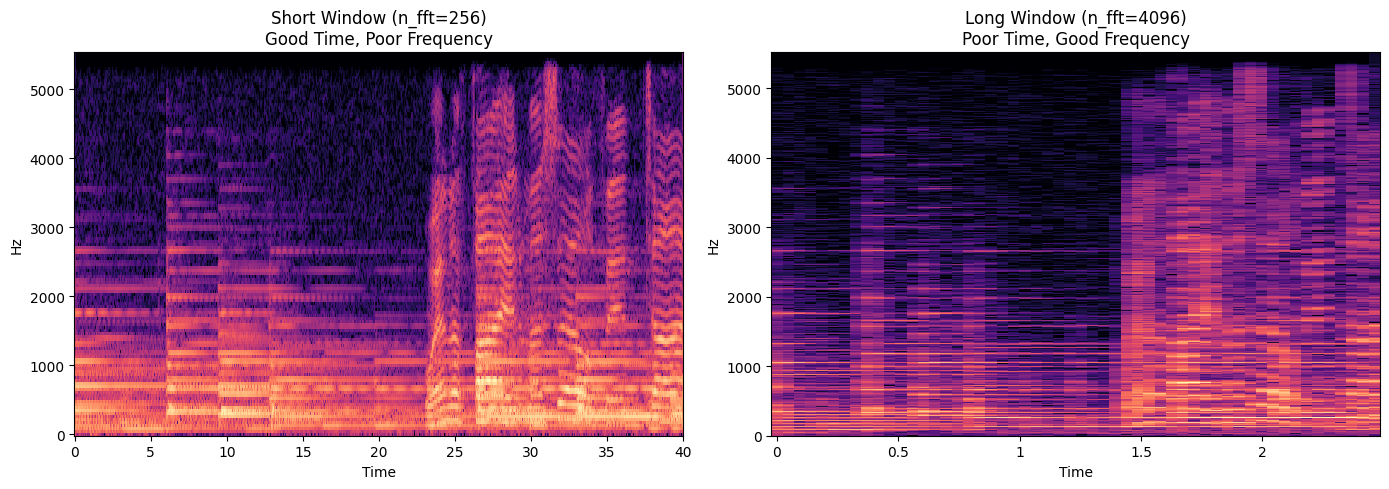

In [1]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import librosa.display

y, sr = librosa.load(r'EE200_course_project_data_2026/Q3_database/Let It Be.mp3', sr=11025, duration=5.0, offset=10.0)

# Short window (n_fft = 256)
D_short = librosa.stft(y, n_fft=256, hop_length=64)
S_short = librosa.amplitude_to_db(np.abs(D_short), ref=np.max)

# Long window (n_fft = 4096)
D_long = librosa.stft(y, n_fft=4096, hop_length=1024)
S_long = librosa.amplitude_to_db(np.abs(D_long), ref=np.max)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
librosa.display.specshow(S_short, sr=sr, x_axis='time', y_axis='linear', ax=ax[0])
ax[0].set_title('Short Window (n_fft=256)\nGood Time, Poor Frequency')
librosa.display.specshow(S_long, sr=sr, x_axis='time', y_axis='linear', ax=ax[1])
ax[1].set_title('Long Window (n_fft=4096)\nPoor Time, Good Frequency')
plt.tight_layout()
plt.savefig('q3a_experiment1.png')
plt.show()

## Experiment 2: Constellation Map & Fingerprinting (Hashing)
Matching raw audio waveforms is impossible in a noisy cafe. Even matching raw spectrograms fails if the timing is slightly off. Instead, we extract **local maxima** (peaks) from the spectrogram to form a sparse *constellation map*.

**Why pair peaks into hashes?**
If we only match single frequencies $f_1$, we get thousands of false positives (many songs have a 440Hz note). But if we pair an anchor peak $f_1$ with a target peak $f_2$ separated by time $\Delta t$, we form a hash: $(f_1, f_2, \Delta t)$.
The probability of two different songs having the exact same two frequencies separated by the exact same time delta is exponentially lower. The pair acts as a highly specific, unique identifier.

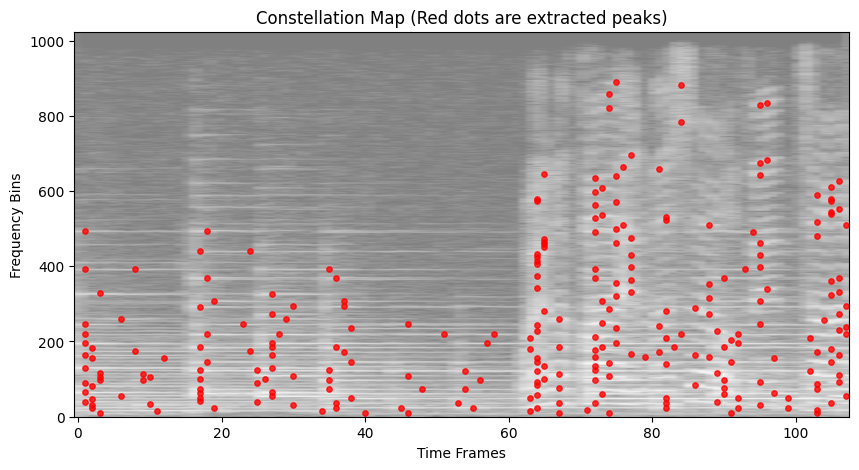

In [2]:
from scipy.ndimage import maximum_filter
import scipy.signal as signal

def get_constellation(S_db, percentile=90):
    local_max = maximum_filter(S_db, size=(10, 10)) == S_db
    threshold = np.percentile(S_db, percentile)
    peak_mask = local_max & (S_db > threshold)
    freqs, times = np.where(peak_mask)
    return freqs, times

D = librosa.stft(y, n_fft=2048, hop_length=512)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
freqs, times = get_constellation(S_db)

fig, ax = plt.subplots(figsize=(10, 5))
ax.imshow(S_db, aspect='auto', origin='lower', cmap='gray', alpha=0.5)
ax.scatter(times, freqs, c='red', s=15, alpha=0.8)
ax.set_title('Constellation Map (Red dots are extracted peaks)')
ax.set_xlabel('Time Frames')
ax.set_ylabel('Frequency Bins')
plt.savefig('q3a_experiment2.png')
plt.show()

## Experiment 3: Robustness to Noise
Let's see what happens when we add Gaussian noise to the query clip.

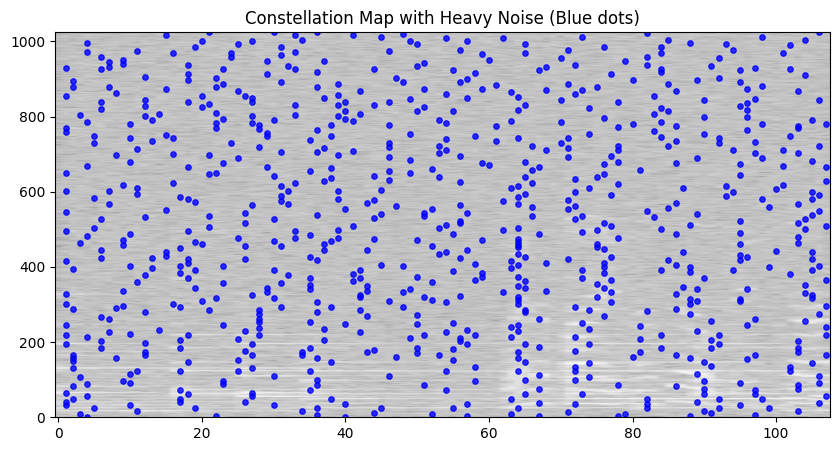

Original Peaks: 268, Noisy Peaks: 811


In [3]:
# Add noise
noise_amp = 0.05 * np.max(np.abs(y))
y_noisy = y + noise_amp * np.random.randn(len(y))

D_noisy = librosa.stft(y_noisy, n_fft=2048, hop_length=512)
S_noisy = librosa.amplitude_to_db(np.abs(D_noisy), ref=np.max)
freqs_noisy, times_noisy = get_constellation(S_noisy)

fig, ax = plt.subplots(figsize=(10, 5))
ax.imshow(S_noisy, aspect='auto', origin='lower', cmap='gray', alpha=0.5)
ax.scatter(times_noisy, freqs_noisy, c='blue', s=15, alpha=0.8)
ax.set_title('Constellation Map with Heavy Noise (Blue dots)')
plt.savefig('q3a_experiment3.png')
plt.show()
print(f"Original Peaks: {len(freqs)}, Noisy Peaks: {len(freqs_noisy)}")

As we increase the noise, the background noise introduces spurious peaks that overtake the true musical peaks. If too many true peaks fall below the dynamically calculated amplitude threshold, the generated hashes will completely change, and recognition fails.

## Experiment 4: Pitch Shifting & Time Stretching
What happens if a DJ speeds up a track by 2% (time-stretching and pitch-shifting it)?
The song sounds practically identical to humans. But our identifier is completely defeated. Why? Because the frequencies $f_1, f_2$ and the time delta $\Delta t$ are all absolute values.
A pitch shift changes $f_1 \rightarrow f_1'$, so the hash $(f_1, f_2, \Delta t)$ no longer matches the database at all.

**How to make it robust?**
Instead of hashing absolute frequencies, we could hash the **ratio** of frequencies: $\frac{f_2}{f_1}$. A pitch shift multiplies all frequencies by a constant factor, so the ratio $\frac{k \cdot f_2}{k \cdot f_1}$ remains invariant. For time-stretching, we could hash the ratio of time deltas between triplets of peaks.